In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [65]:
# Configuring display settings
plt.rcParams['figure.figsize'] = (12, 9)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

In [80]:
# Correcting file paths to match the actual directory structure
data_dir = 'data'
employee_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'employee_survey_data.csv'))
general_data = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'general_data.csv'))
manager_survey = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'manager_survey_data.csv'))
in_time = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time', 'in_time.csv'))
out_time = pd.read_csv(os.path.join(os.getcwd(), data_dir, 'in_out_time' ,'out_time.csv'))

in_time.rename(columns={in_time.columns[0]: 'EmployeeID'}, inplace=True)
out_time.rename(columns={out_time.columns[0]: 'EmployeeID'}, inplace=True)

# Merging datasets
employee_data = pd.merge(general_data, employee_survey, on='EmployeeID', how='left')
employee_data = pd.merge(employee_data, manager_survey, on='EmployeeID', how='left')
#employee_data = pd.merge(employee_data, in_time, on='EmployeeID', how='left')
#employee_data = pd.merge(employee_data, out_time, on='EmployeeID', how='left')

# Displaying the first few rows of the merged dataset
employee_data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.00,Y,11,8,0,1.00,6,1,0,0,3.00,4.00,2.00,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.00,Y,23,8,1,6.00,3,5,1,4,3.00,2.00,4.00,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.00,Y,15,8,3,5.00,2,5,0,3,2.00,2.00,1.00,3,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.00,Y,11,8,3,13.00,5,8,7,5,4.00,4.00,3.00,2,3
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.00,Y,12,8,2,9.00,2,6,0,4,4.00,1.00,3.00,3,3


Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
EnvironmentSatisfaction    0
JobSatisfaction            0
WorkLifeBalance            0
JobInvolvement             0
PerformanceRating          0
dtype: int64

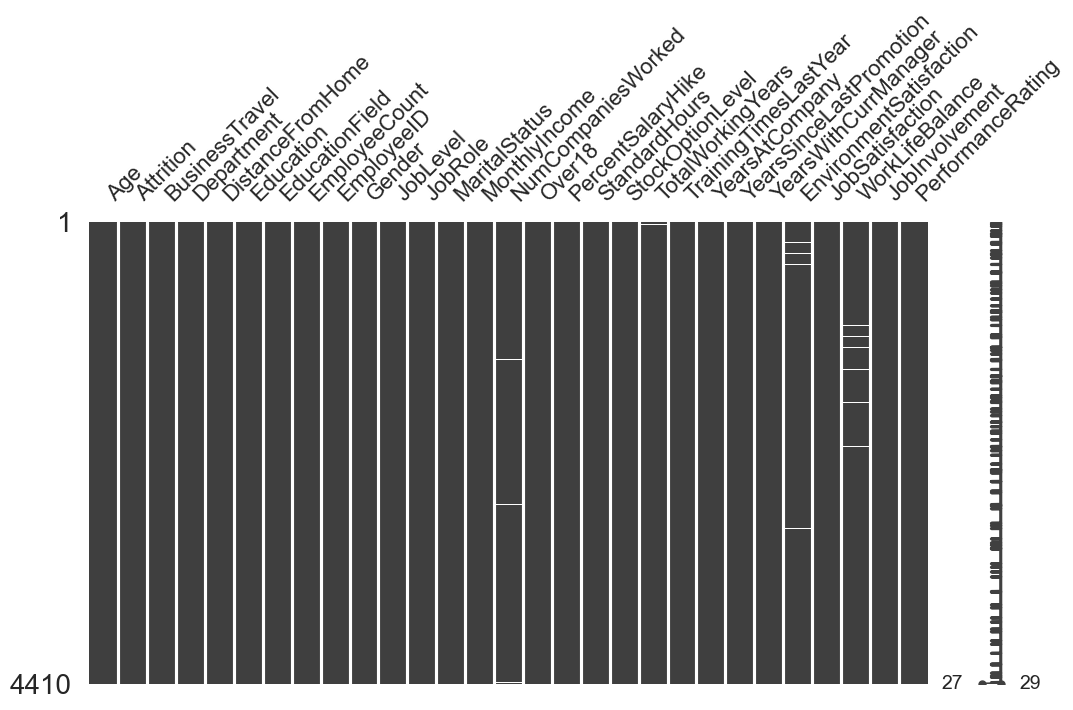

In [81]:
import missingno as msno

# Visualizing missing data
msno.matrix(employee_data[employee_data.columns], figsize=(12, 6))

# Impute missing values
# For numerical columns, use median imputation
numerical_columns = employee_data.select_dtypes(include=['float64', 'int64']).columns
employee_data[numerical_columns] = employee_data[numerical_columns].fillna(employee_data[numerical_columns].median())

# For categorical columns, use mode imputation
employee_data['Over18'] = employee_data['Over18'].fillna('N')
categorical_columns = employee_data.select_dtypes(include=['object']).columns
employee_data[categorical_columns] = employee_data[categorical_columns].fillna(employee_data[categorical_columns].mode().iloc[0])

# Verify that there are no more missing values
employee_data.isnull().sum()

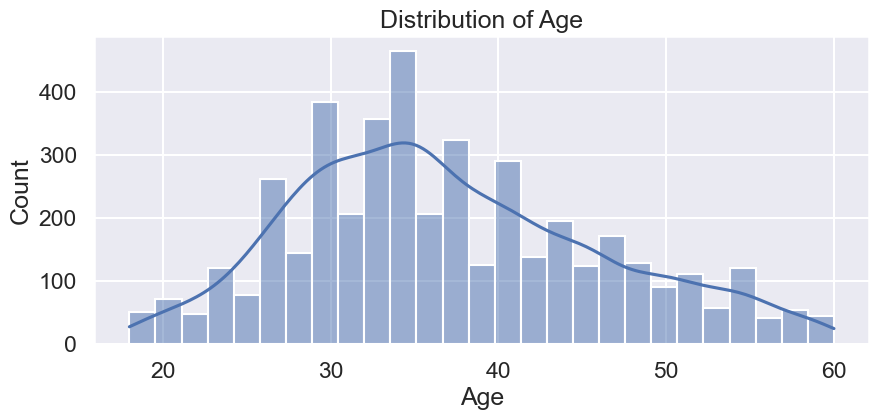

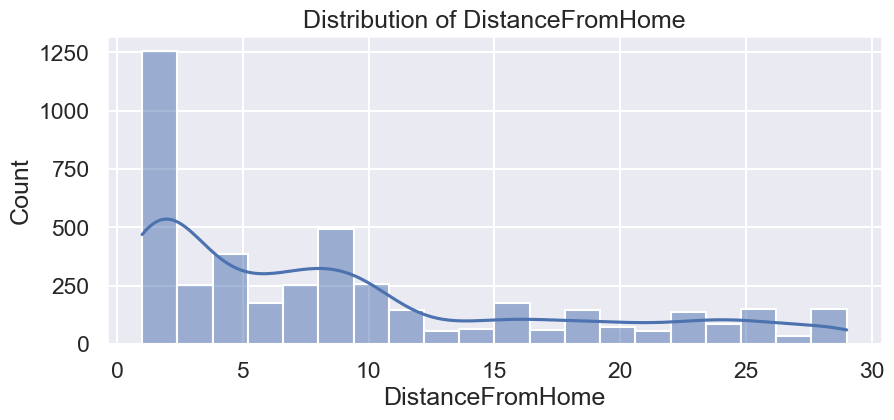

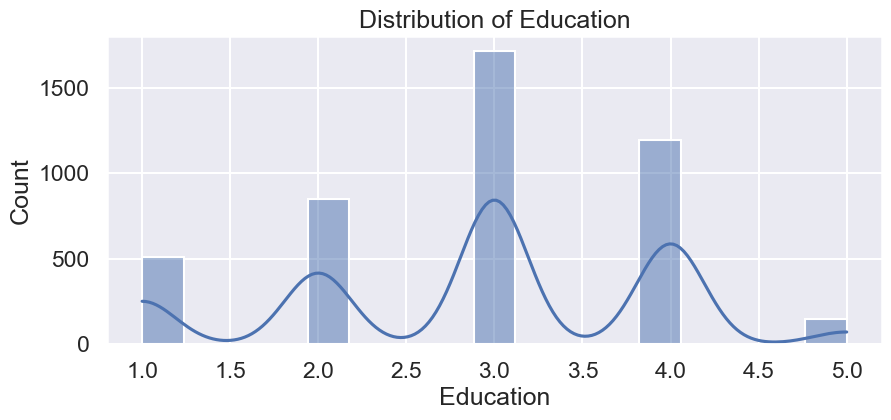

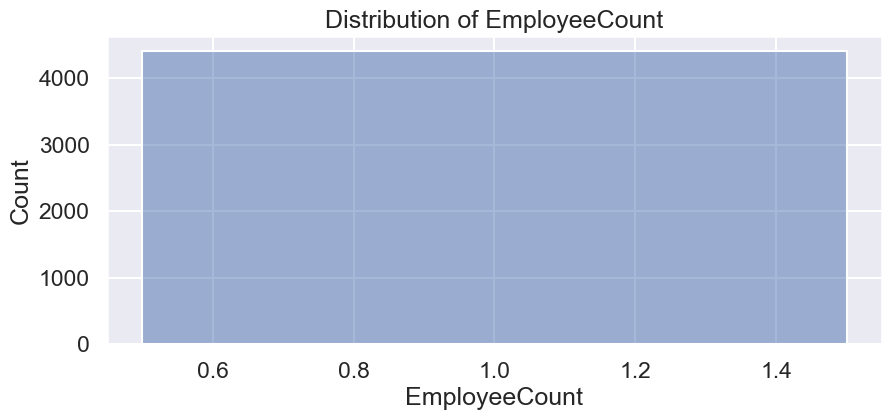

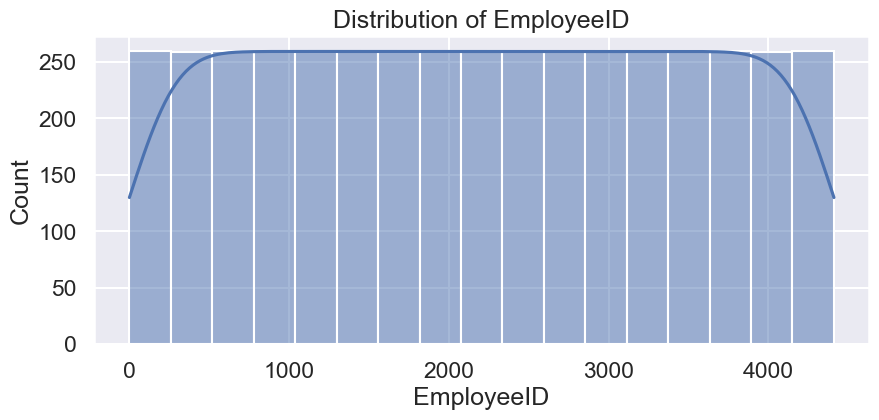

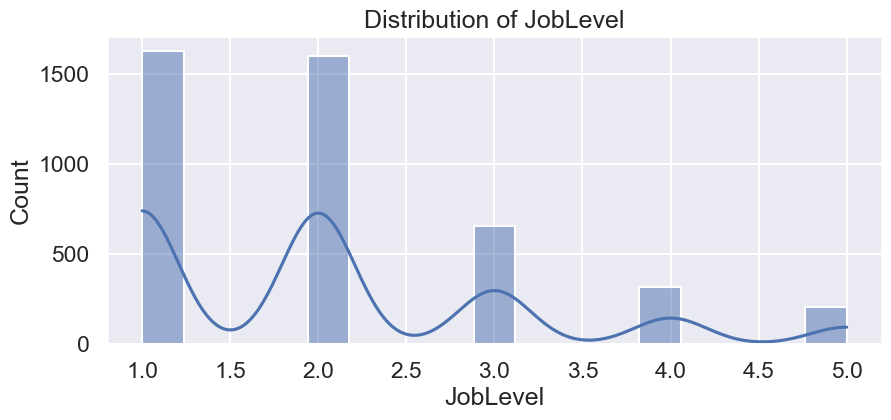

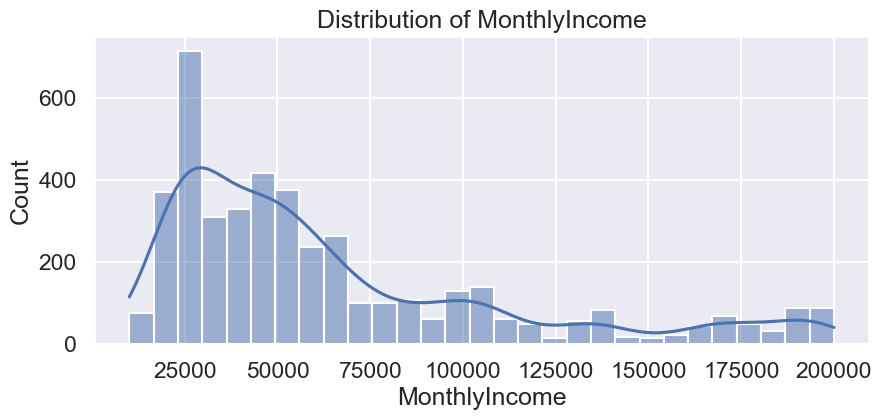

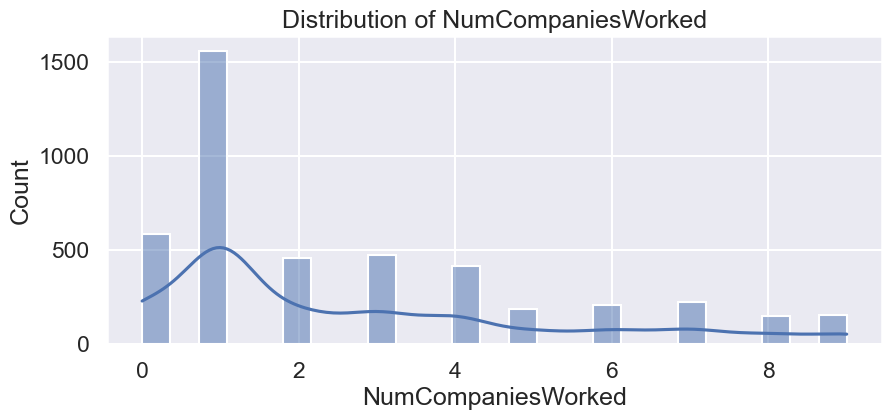

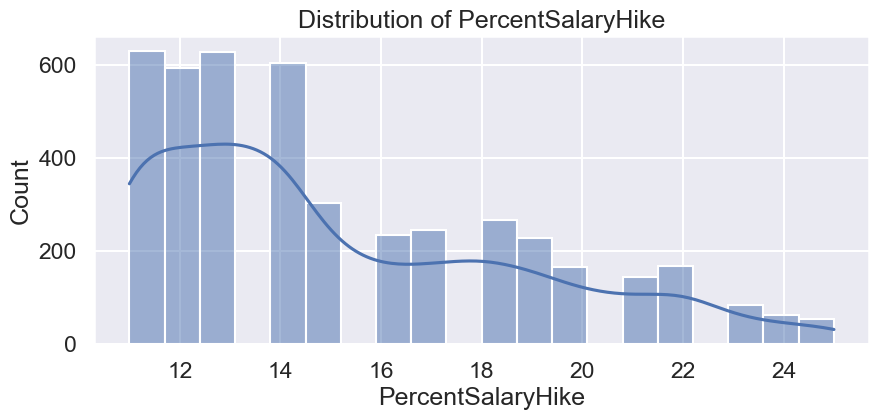

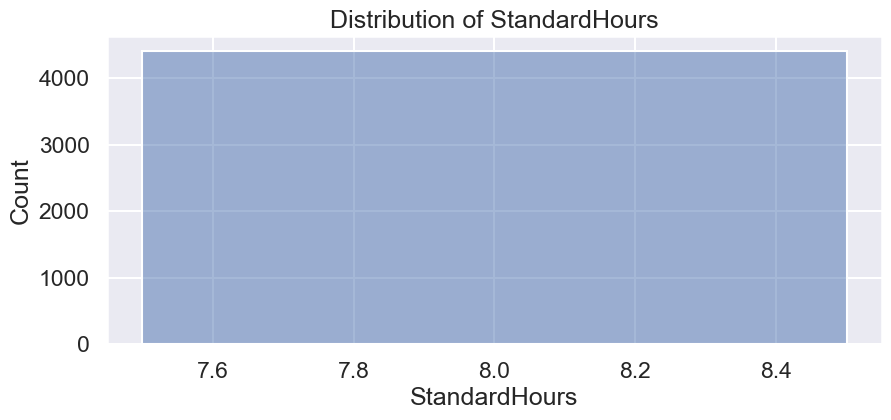

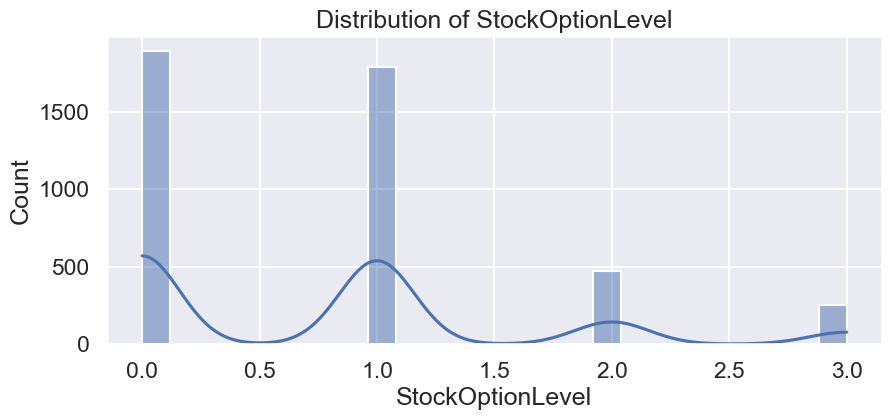

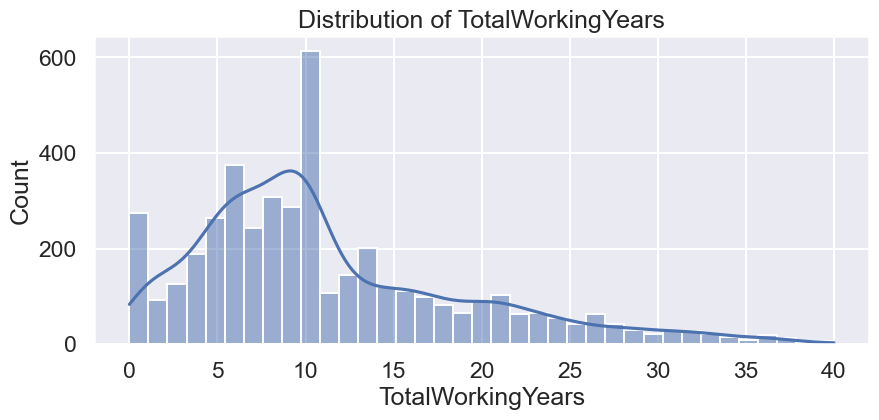

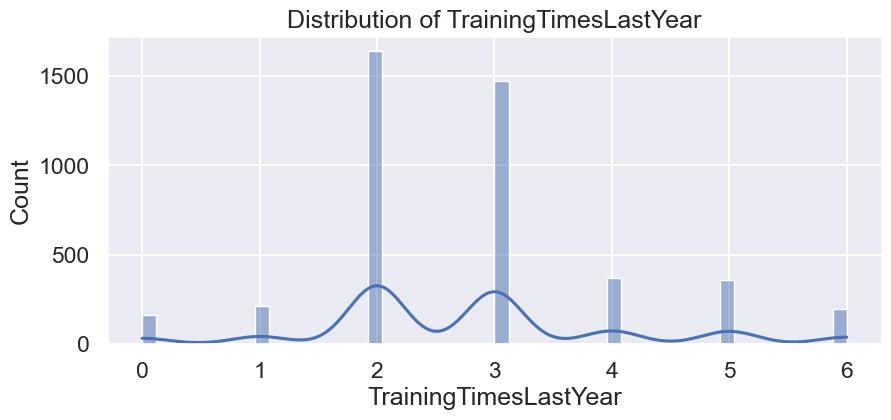

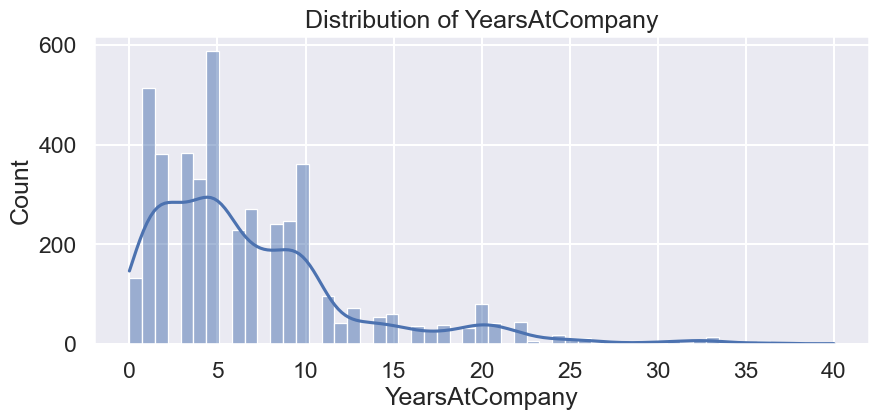

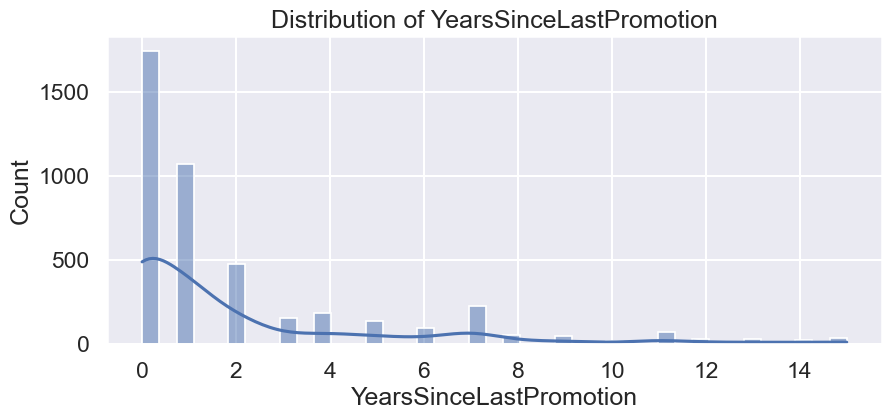

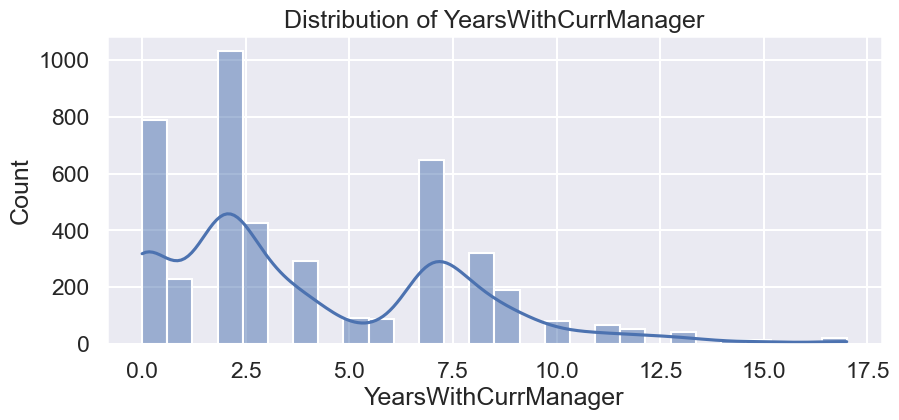

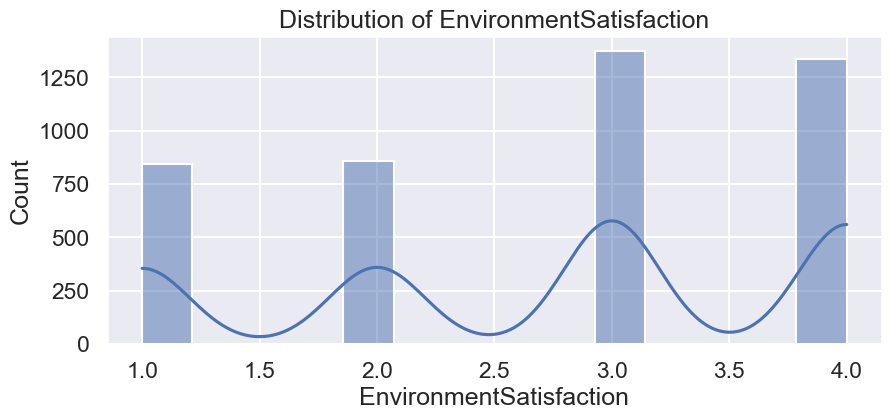

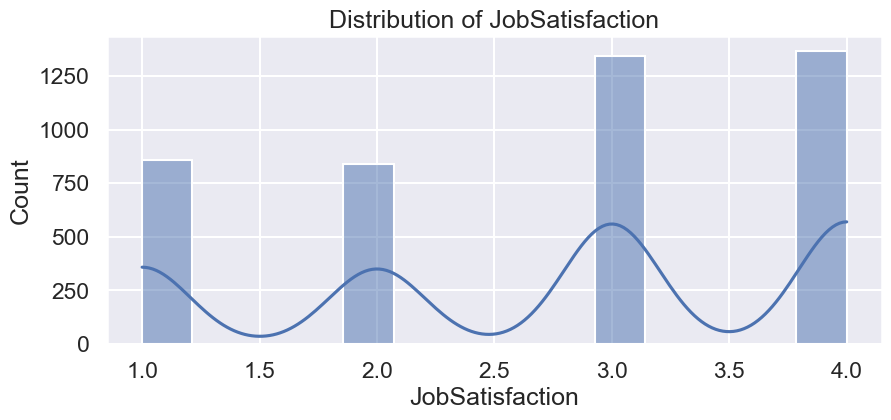

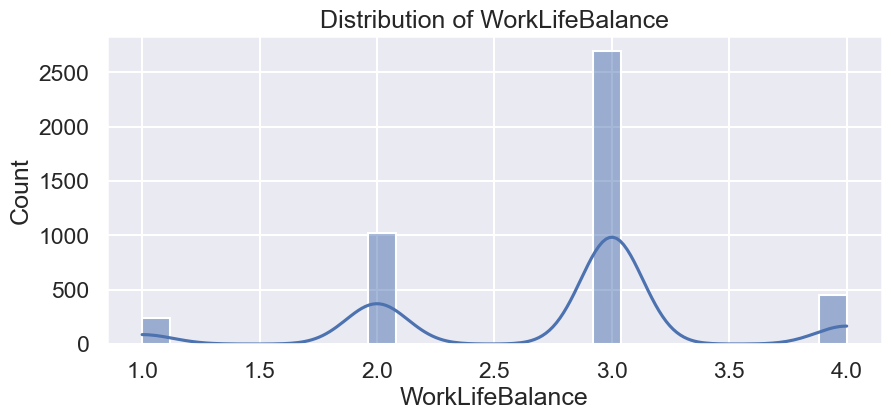

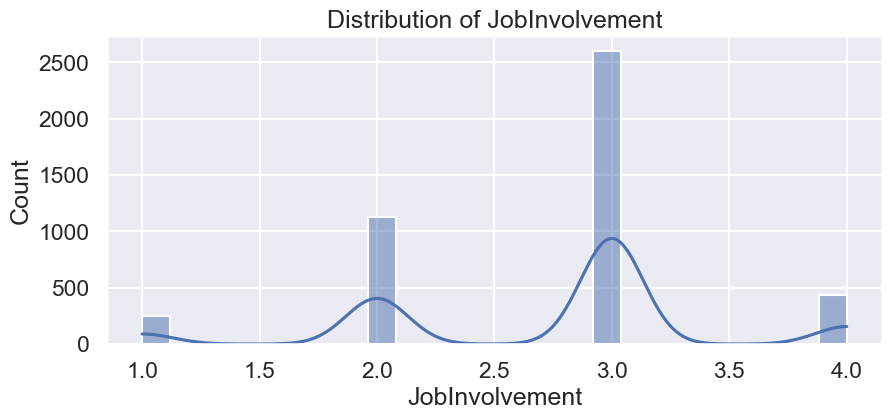

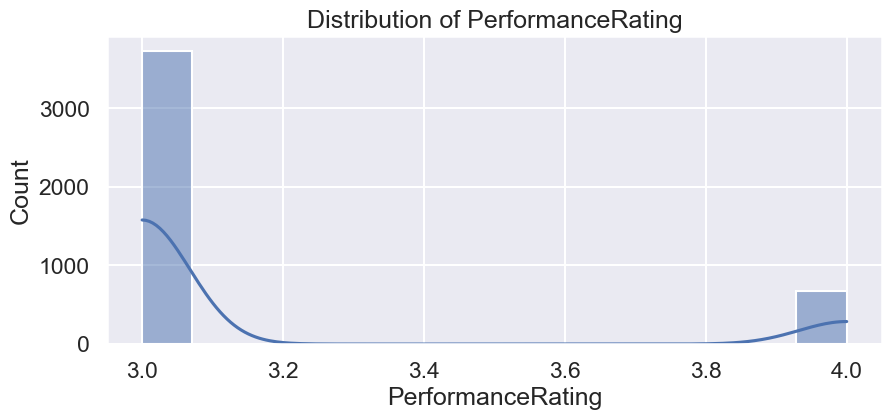

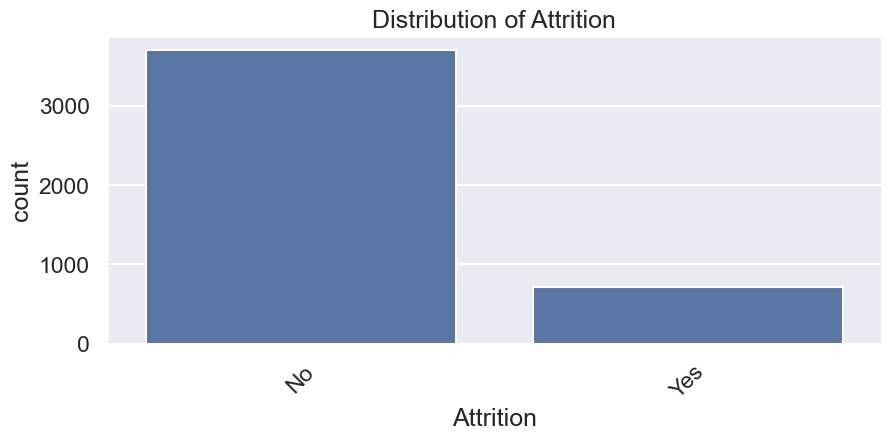

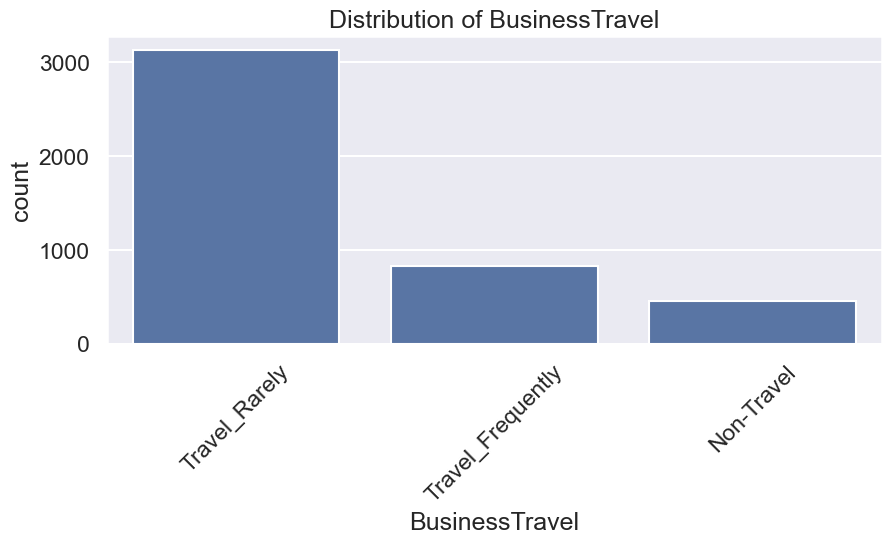

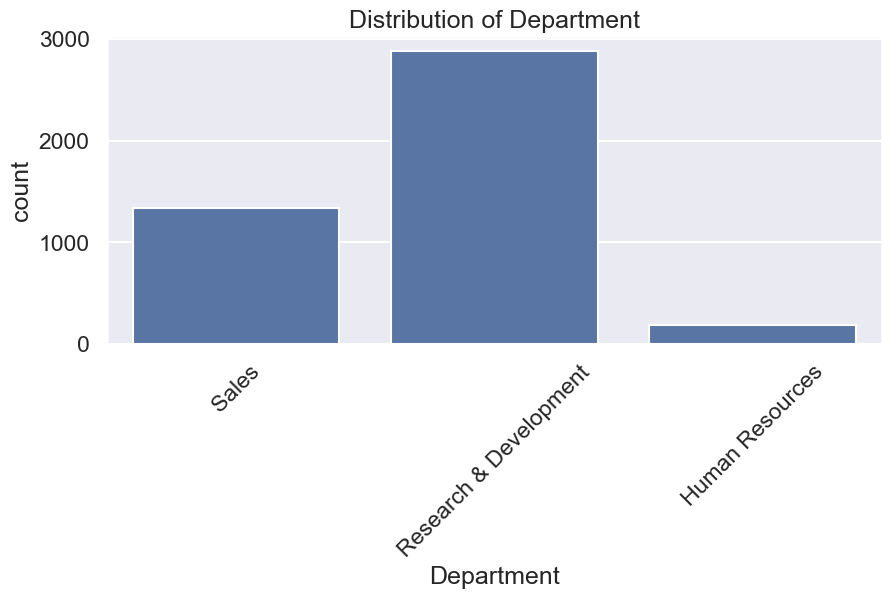

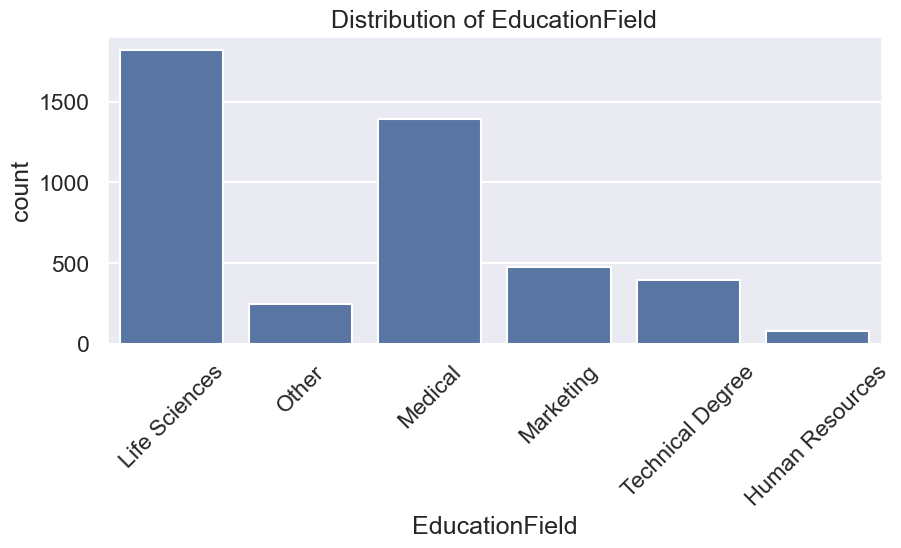

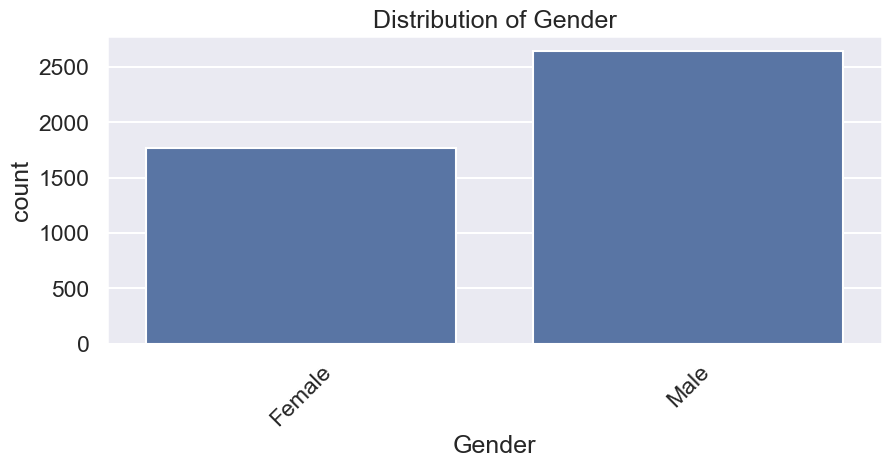

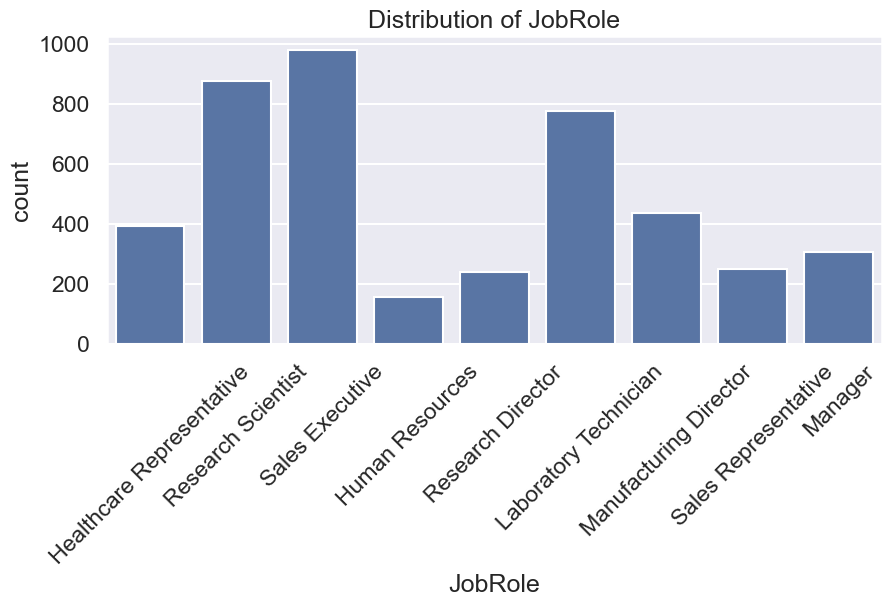

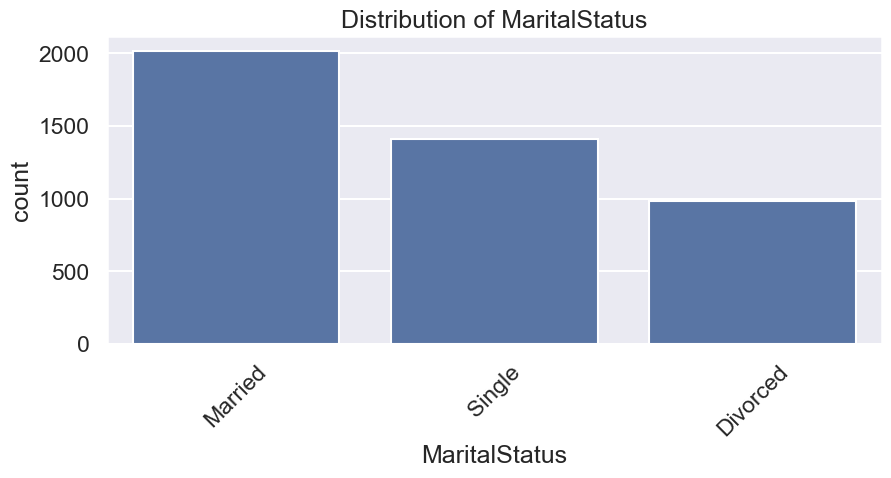

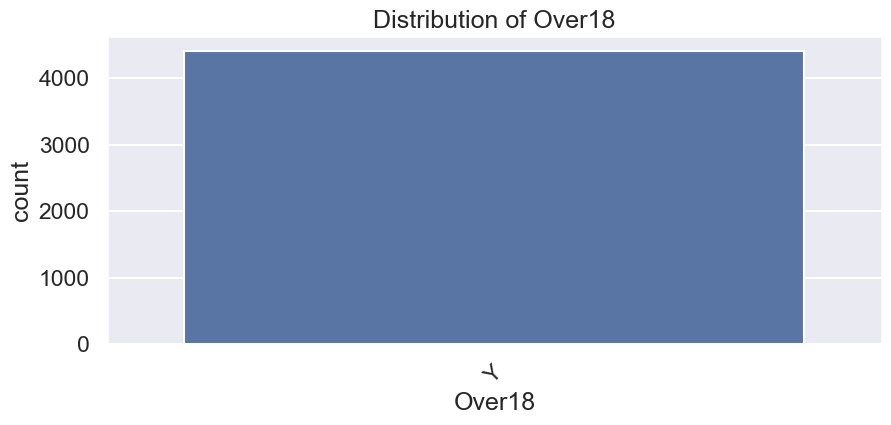

In [78]:
# Univariate analysis for numerical features
for column in numerical_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(employee_data[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.show()

# Univariate analysis for categorical features
for column in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=employee_data[column])
    plt.title(f'Distribution of {column}')
    plt.xticks(rotation=45)
    plt.show()